<a href="https://colab.research.google.com/github/AlexCayarga/Rentwise-NYC/blob/main/notebooks/Exploratory_Data_Analysis_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("completely_cleaned_train.csv")

Saving completely_cleaned_train.csv to completely_cleaned_train.csv


# **1. Dataset Overview**

In [4]:
df.shape

(45039, 15)

In [5]:
df.head()

,bedrooms,bathrooms,latitude,listing_id,longitude,price,has_laundry,has_elevator,has_doorman,has_dishwasher,has_hardwood,has_no_fee,pets_allowed,num_features,is_studio
0,1,1.0,40.7108,7170325,-73.9539,2400,1,0,0,1,1,0,1,7,0
1,2,1.0,40.7513,7092344,-73.9722,3800,1,1,1,1,1,1,0,6,0
2,2,1.0,40.7575,7158677,-73.9625,3495,1,1,1,1,1,0,0,6,0
3,3,1.5,40.7145,7211212,-73.9425,3000,0,0,0,0,0,0,0,0,0
4,0,1.0,40.7439,7225292,-73.9743,2795,1,1,1,0,0,0,0,4,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45039 entries, 0 to 45038
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bedrooms        45039 non-null  int64  
 1   bathrooms       45039 non-null  float64
 2   latitude        45039 non-null  float64
 3   listing_id      45039 non-null  int64  
 4   longitude       45039 non-null  float64
 5   price           45039 non-null  int64  
 6   has_laundry     45039 non-null  int64  
 7   has_elevator    45039 non-null  int64  
 8   has_doorman     45039 non-null  int64  
 9   has_dishwasher  45039 non-null  int64  
 10  has_hardwood    45039 non-null  int64  
 11  has_no_fee      45039 non-null  int64  
 12  pets_allowed    45039 non-null  int64  
 13  num_features    45039 non-null  int64  
 14  is_studio       45039 non-null  int64  
dtypes: float64(3), int64(12)
memory usage: 5.2 MB


In [7]:
df.describe()

,bedrooms,bathrooms,latitude,listing_id,longitude,price,has_laundry,has_elevator,has_doorman,has_dishwasher,has_hardwood,has_no_fee,pets_allowed,num_features,is_studio
count,45039.000000,45039.000000,45039.000000,4.503900e+04,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000,45039.000000
mean,1.486712,1.146162,40.750856,7.023745e+06,-73.971554,3238.876285,0.474478,0.513910,0.397589,0.414108,0.504318,0.363041,0.472923,5.261973,0.205133
std,1.107562,0.374344,0.040317,1.263664e+05,0.030089,1159.084395,0.499354,0.499812,0.489405,0.492573,0.499987,0.480882,0.499272,3.840733,0.403804
min,0.000000,1.000000,40.506500,6.811957e+06,-74.243200,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,40.727900,6.915608e+06,-73.991300,2450.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
50%,1.000000,1.000000,40.751600,7.020011e+06,-73.977300,3000.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000
75%,2.000000,1.000000,40.774200,7.128384e+06,-73.953900,3795.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,0.000000
max,5.000000,4.000000,40.915400,7.753784e+06,-73.700100,10000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000,1.000000


# **2. Variable Distribution**

In [8]:
df["bedrooms"].value_counts().sort_index()

,count
bedrooms,
0,9239
1,15138
2,12244
3,6519
4,1718
5,181


In [9]:
df["bathrooms"].value_counts().sort_index()

,count
bathrooms,
1.0,38559
1.5,560
2.0,5529
2.5,111
3.0,227
3.5,11
4.0,42


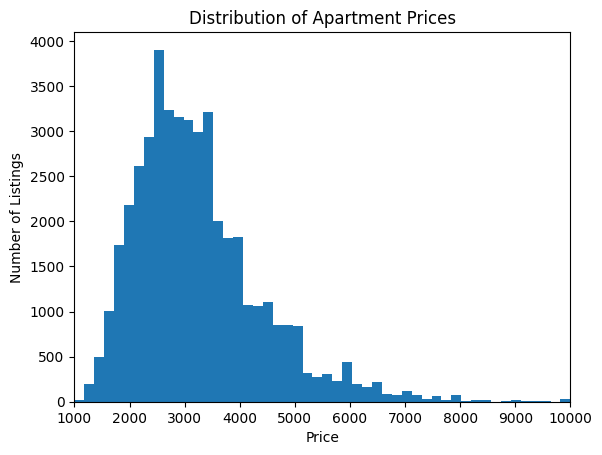

In [10]:
import matplotlib.pyplot as plt

df["price"].plot(kind="hist", bins=50)

plt.xlim(1000, 10000)
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Apartment Prices")
plt.show()

In [11]:
df["price"].describe()

,price
count,45039.000000
mean,3238.876285
std,1159.084395
min,1000.000000
25%,2450.000000
50%,3000.000000
75%,3795.000000
max,10000.000000


In [12]:
df.groupby("bedrooms")["price"].median()

,price
bedrooms,
0,2400.0
1,2895.0
2,3200.0
3,4350.0
4,5725.0
5,7000.0


<Axes: xlabel='longitude', ylabel='latitude'>

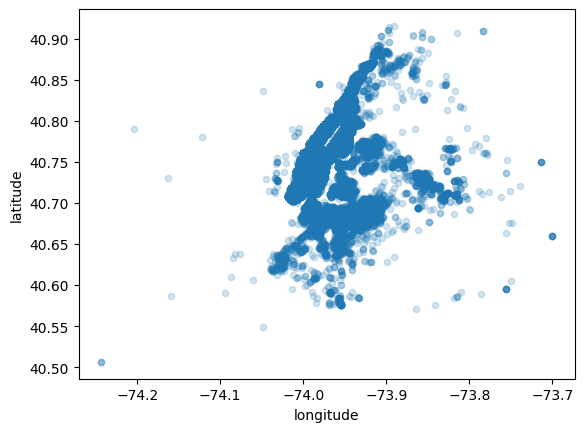

In [21]:
df.plot.scatter(x="longitude", y="latitude", alpha=0.2)

In [24]:
amenity_cols = [
    "has_laundry", "has_elevator", "has_doorman",
    "has_dishwasher", "has_hardwood", "has_no_fee",
    "pets_allowed"
]

for col in amenity_cols:
    print(col)
    print(df.groupby(col)["price"].median())
    print()

has_laundry
has_laundry
0    2750.0
1    3300.0
Name: price, dtype: float64

has_elevator
has_elevator
0    2750.0
1    3274.0
Name: price, dtype: float64

has_doorman
has_doorman
0    2750.0
1    3395.0
Name: price, dtype: float64

has_dishwasher
has_dishwasher
0    2757.0
1    3349.0
Name: price, dtype: float64

has_hardwood
has_hardwood
0    2900.0
1    3127.0
Name: price, dtype: float64

has_no_fee
has_no_fee
0    2850.0
1    3290.0
Name: price, dtype: float64

pets_allowed
pets_allowed
0    2950.0
1    3100.0
Name: price, dtype: float64



In [23]:
amenity_cols = [
    "has_laundry", "has_elevator", "has_doorman",
    "has_dishwasher", "has_hardwood", "has_no_fee",
    "pets_allowed"
]

for col in amenity_cols:
    print(col)
    print(df.groupby(col)["price"].mean())
    print()

has_laundry
has_laundry
0    2980.801682
1    3524.714740
Name: price, dtype: float64

has_elevator
has_elevator
0    3009.829306
1    3455.523892
Name: price, dtype: float64

has_doorman
has_doorman
0    3009.662060
1    3586.172893
Name: price, dtype: float64

has_dishwasher
has_dishwasher
0    2977.536721
1    3608.627419
Name: price, dtype: float64

has_hardwood
has_hardwood
0    3104.385129
1    3371.064145
Name: price, dtype: float64

has_no_fee
has_no_fee
0    3080.160276
1    3517.345178
Name: price, dtype: float64

pets_allowed
pets_allowed
0    3181.714563
1    3302.583427
Name: price, dtype: float64



In [25]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.000000
bedrooms,0.630505
bathrooms,0.584539
num_features,0.281295
has_dishwasher,0.268193
has_doorman,0.243423
has_laundry,0.234327
has_elevator,0.192189
has_no_fee,0.181380
has_hardwood,0.115036
